In [1]:
# 6-18-2026

In [22]:
import xarray as xr
import numpy as np
import pandas as pd
import regionmask
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.spatial import cKDTree

In [23]:
zarr_path = "seasfire_pyromes_ecoregions.zarr"

In [24]:
ds = xr.open_zarr(zarr_path, consolidated=True)
df = pd.read_csv("ecoregions_stats.csv")

In [25]:
ds

<xarray.Dataset> Size: 76GB
Dimensions:                         (latitude: 720, longitude: 1440, time: 506)
Coordinates:
  * latitude                        (latitude) float64 6kB 89.88 ... -89.88
  * longitude                       (longitude) float64 12kB -179.9 ... 179.9
  * time                            (time) datetime64[ns] 4kB 2011-01-01 ... ...
Data variables: (12/43)
    area                            (latitude, longitude) float32 4MB dask.array<chunksize=(45, 45), meta=np.ndarray>
    biomes                          (latitude, longitude) float32 4MB dask.array<chunksize=(45, 45), meta=np.ndarray>
    cams_co2fire                    (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    cams_frpfire                    (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    drought_code_max                (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    drought_code_mean               (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    ...                              ...
    t2m_max                         (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    t2m_mean                        (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    t2m_min                         (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    tp                              (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    vpd                             (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
    ws10                            (time, latitude, longitude) float32 2GB dask.array<chunksize=(506, 45, 45), meta=np.ndarray>
Attributes:
    crs:          EPSG:4326
    description:  The SeasFire Cube is a scientific datacube for seasonal fir...
    title:        SeasFire Cube: A Global Dataset for Seasonal Fire Modeling ...

In [26]:
df

,ecoregion_id,ndvi_mean,ndvi_std,tp_mean,tp_std,t2m_mean_mean,t2m_mean_std,vpd_mean,vpd_std,fwi_mean_mean,fwi_mean_std
0,10101.0,0.861981,0.018632,87.606900,46.894028,300.05972,0.495307,7.156866,1.218896,0.523723,1.157128
1,10102.0,0.811376,0.056275,41.696075,44.840942,299.99167,0.916401,8.344715,1.445781,5.379829,7.148313
2,10103.0,0.831247,0.016678,73.235190,37.511982,300.35510,0.404653,7.995025,0.804152,0.309281,0.589486
3,10104.0,0.818266,0.037402,75.606750,50.415367,297.25217,1.323315,5.550790,1.390918,1.663618,4.157984
4,10105.0,0.804765,0.037594,133.072220,83.581340,293.26993,3.177103,4.774403,1.419347,0.165741,0.525632
...,...,...,...,...,...,...,...,...,...,...,...
786,81329.0,0.096504,0.013685,0.478033,2.007010,300.93298,6.504858,32.736767,12.275587,76.862015,16.856901
787,81330.0,0.079987,0.063435,2.011220,5.163428,284.36990,13.093088,13.684868,10.943560,43.847490,23.136137
788,81331.0,0.089542,0.012297,0.756772,4.336491,295.88806,6.333597,24.953905,9.702799,63.496370,14.658874
789,81332.0,0.100678,0.014361,0.659456,2.479339,297.66815,7.632448,28.720503,12.799202,71.168530,17.144644


In [27]:
feature_cols = [
    "ndvi_mean",
    "ndvi_std",
    "tp_mean",
    "tp_std",
    "t2m_mean_mean",
    "t2m_mean_std",
    "vpd_mean",
    "vpd_std",
    "fwi_mean_mean",
    "fwi_mean_std"
]

df_scaled = df.copy()

In [28]:
df_scaled["ecoregion_id"] = df_scaled["ecoregion_id"].astype(int) # original had .0 at end 

In [29]:
scaler = StandardScaler()

df_scaled[feature_cols] = scaler.fit_transform(
    df_scaled[feature_cols]
)

df_scaled.head()

,ecoregion_id,ndvi_mean,ndvi_std,tp_mean,tp_std,t2m_mean_mean,t2m_mean_std,vpd_mean,vpd_std,fwi_mean_mean,fwi_mean_std
0,10101,1.583927,-1.436430,2.349207,0.818652,0.974691,-1.223407,-0.313550,-0.973492,-0.894021,-1.364158
1,10102,1.364330,-0.937810,0.478327,0.714218,0.968130,-1.122366,-0.098350,-0.901506,-0.569004,-0.546033
2,10103,1.450560,-1.462310,1.763555,0.341418,1.003170,-1.245159,-0.161702,-1.105081,-0.908373,-1.441672
3,10104,1.394231,-1.187800,1.860197,0.997771,0.704001,-1.024727,-0.604520,-0.918913,-0.817728,-0.954377
4,10105,1.335644,-1.185254,4.201932,2.684818,0.320053,-0.579913,-0.745177,-0.909893,-0.917980,-1.450391


In [30]:
df_scaled[feature_cols].mean()

ndvi_mean       -1.361193e-16
ndvi_std         5.444772e-17
tp_mean         -4.491421e-17
tp_std           3.593136e-17
t2m_mean_mean   -3.754828e-15
t2m_mean_std     1.077941e-16
vpd_mean         1.796568e-17
vpd_std         -1.976225e-16
fwi_mean_mean   -7.259696e-17
fwi_mean_std    -2.132536e-16
dtype: float64

In [31]:
df_scaled[feature_cols].std() # perfect

ndvi_mean        1.000639
ndvi_std         1.000639
tp_mean          1.000633
tp_std           1.000633
t2m_mean_mean    1.000633
t2m_mean_std     1.000633
vpd_mean         1.000633
vpd_std          1.000633
fwi_mean_mean    1.000639
fwi_mean_std     1.000639
dtype: float64

In [32]:
print(list(ds.data_vars))

['area', 'biomes', 'cams_co2fire', 'cams_frpfire', 'drought_code_max', 'drought_code_mean', 'ecoregion', 'fcci_ba', 'fcci_ba_valid_mask', 'fcci_fraction_of_burnable_area', 'fcci_fraction_of_observed_area', 'fcci_number_of_patches', 'fwi_max', 'fwi_mean', 'gwis_ba', 'gwis_ba_valid_mask', 'lai', 'lccs_class_1', 'lccs_class_2', 'lccs_class_3', 'lccs_class_4', 'lccs_class_6', 'lccs_class_7', 'lsm', 'lst_day', 'ndvi', 'pop_dens', 'pyrome', 'rel_hum', 'skt', 'ssr', 'ssrd', 'sst', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 't2m_max', 't2m_mean', 't2m_min', 'tp', 'vpd', 'ws10']


In [33]:
import numpy as np
from collections import defaultdict
from scipy.sparse import csr_matrix

In [34]:
eco = ds["ecoregion"].values
eco = np.where(np.isnan(eco), 0, eco).astype(int)

In [35]:
feature_cols = [
    "ndvi_mean",
    "ndvi_std",
    "tp_mean",
    "tp_std",
    "t2m_mean_mean",
    "t2m_mean_std",
    "vpd_mean",
    "vpd_std",
    "fwi_mean_mean",
    "fwi_mean_std"
]

df_sorted = df_scaled.sort_values("ecoregion_id").reset_index(drop=True)

# drop nan in climate features
df_clean = df_sorted.dropna(subset=feature_cols).reset_index(drop=True)

# keep only ecoregions that actually have raster pixels
# this is what closes the gap between the feature table and the raster grid
raster_ids = set(np.unique(eco)) - {0}
n_before = len(df_clean)
df_clean = df_clean[df_clean["ecoregion_id"].isin(raster_ids)].reset_index(drop=True)
n_dropped = n_before - len(df_clean)
print(f"dropped {n_dropped} ecoregions with no raster footprint")

X = df_clean[feature_cols].to_numpy()
ecoregion_ids = df_clean["ecoregion_id"].to_numpy()

dropped 0 ecoregions with no raster footprint


In [36]:
id_to_idx = {eid: i for i, eid in enumerate(ecoregion_ids)}

In [37]:
from scipy.sparse import lil_matrix

rows, cols = eco.shape

neighbors = [
    (-1,-1), (-1,0), (-1,1),
    (0,-1),         (0,1),
    (1,-1), (1,0),  (1,1)
]

connectivity = lil_matrix((len(ecoregion_ids), len(ecoregion_ids)), dtype=np.int8)

for r in range(rows):
    for c in range(cols):
        a = eco[r, c]
        if a == 0 or a not in id_to_idx:
            continue

        i = id_to_idx[a]

        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc

            if 0 <= nr < rows and 0 <= nc < cols:
                b = eco[nr, nc]

                if b == 0 or b not in id_to_idx:
                    continue

                j = id_to_idx[b]

                if i != j:
                    connectivity[i, j] = 1
                    connectivity[j, i] = 1

connectivity = connectivity.tocsr()

In [38]:
lat = ds["latitude"].values
lon = ds["longitude"].values

coords = {eid: [] for eid in ecoregion_ids}

for r in range(rows):
    for c in range(cols):
        eid = eco[r, c]
        if eid == 0 or eid not in id_to_idx:
            continue
        coords[eid].append((lat[r], lon[c]))

centroids = np.array([
    np.mean(coords[eid], axis=0)
    for eid in ecoregion_ids
])

In [39]:
from scipy.sparse.csgraph import connected_components

def haversine_distance(coords1, coords2):
    # coords are (lat, lon) in degrees, returns distance in km
    lat1 = np.radians(coords1[:, 0])[:, None]
    lon1 = np.radians(coords1[:, 1])[:, None]
    lat2 = np.radians(coords2[:, 0])[None, :]
    lon2 = np.radians(coords2[:, 1])[None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(a))

    earth_radius_km = 6371.0
    return earth_radius_km * c

def bridge_components(connectivity, centroids):
    # connects the globally closest pair of nodes across two different
    # components, one merge at a time, until the whole graph is one
    # component, this also clears any zero-degree node along the way
    connectivity = connectivity.tolil()
    n_components, labels = connected_components(connectivity, directed=False)

    while n_components > 1:
        best_dist = np.inf
        best_pair = None

        for a in range(n_components):
            idx_a = np.where(labels == a)[0]
            for b in range(a + 1, n_components):
                idx_b = np.where(labels == b)[0]

                dists = haversine_distance(centroids[idx_a], centroids[idx_b])
                local_min = np.unravel_index(np.argmin(dists), dists.shape)

                if dists[local_min] < best_dist:
                    best_dist = dists[local_min]
                    best_pair = (idx_a[local_min[0]], idx_b[local_min[1]])

        i, j = best_pair
        connectivity[i, j] = 1
        connectivity[j, i] = 1

        n_components, labels = connected_components(connectivity, directed=False)

    return connectivity.tocsr()

connectivity = bridge_components(connectivity, centroids)

In [40]:
from scipy.sparse.csgraph import connected_components

n_components, component_labels = connected_components(connectivity, directed=False)
degrees = np.array(connectivity.sum(axis=1)).flatten()

print("components:", n_components)
print("X NaNs:", np.isnan(X).sum())
print("min degree:", degrees.min())
print("component sizes:", np.bincount(component_labels))

components: 1
X NaNs: 0
min degree: 1
component sizes: [779]


In [41]:
from sklearn.cluster import AgglomerativeClustering

target_total_clusters = 50
cluster_labels = np.full(len(ecoregion_ids), -1, dtype=int)
next_cluster_id = 0

for comp in range(n_components):
    idx = np.where(component_labels == comp)[0]

    if len(idx) == 1:
        # true geographic isolate at this raster resolution, gets its own cluster
        cluster_labels[idx] = next_cluster_id
        next_cluster_id += 1
        continue

    sub_connectivity = connectivity[idx][:, idx]
    sub_X = X[idx]

    n_sub_clusters = max(1, round(target_total_clusters * len(idx) / len(ecoregion_ids)))
    n_sub_clusters = min(n_sub_clusters, len(idx))

    model = AgglomerativeClustering(
        n_clusters=n_sub_clusters,
        metric="euclidean",
        linkage="ward",
        connectivity=sub_connectivity
    )

    sub_labels = model.fit_predict(sub_X)
    cluster_labels[idx] = sub_labels + next_cluster_id
    next_cluster_id += sub_labels.max() + 1

labels = cluster_labels
print("total clusters produced:", len(np.unique(labels)))

total clusters produced: 50


In [42]:
component_sizes = np.bincount(component_labels)

for comp in np.argsort(component_sizes):
    idx = np.where(component_labels == comp)[0]
    print(f"component {comp}: {len(idx)} ecoregions, ids {ecoregion_ids[idx].tolist()}")

component 0: 779 ecoregions, ids [10101, 10102, 10103, 10104, 10105, 10106, 10107, 10108, 10110, 10111, 10112, 10113, 10115, 10116, 10117, 10118, 10119, 10120, 10121, 10122, 10123, 10124, 10125, 10126, 10127, 10128, 10201, 10202, 10203, 10204, 10401, 10402, 10403, 10404, 10405, 10406, 10407, 10408, 10409, 10410, 10411, 10412, 10413, 10414, 10701, 10702, 10703, 10704, 10705, 10706, 10707, 10708, 10709, 10801, 10802, 10803, 11001, 11002, 11003, 11101, 11201, 11202, 11203, 11204, 11205, 11206, 11207, 11208, 11209, 11210, 11301, 11302, 11303, 11304, 11305, 11306, 11307, 11308, 11309, 11310, 11401, 21103, 21104, 30101, 30102, 30103, 30104, 30105, 30106, 30107, 30108, 30109, 30110, 30111, 30112, 30114, 30116, 30117, 30118, 30119, 30120, 30121, 30122, 30123, 30124, 30125, 30126, 30127, 30128, 30129, 30130, 30201, 30202, 30203, 30701, 30702, 30704, 30705, 30706, 30707, 30708, 30709, 30710, 30711, 30712, 30713, 30714, 30715, 30716, 30717, 30718, 30719, 30721, 30722, 30723, 30724, 30725, 30726, 

In [43]:
import matplotlib.pyplot as plt

# map each ecoregion id to its domain label, then broadcast to every pixel
# using a lookup array, vectorized instead of a double for loop since eco
# can be a few million pixels
max_id = eco.max()
lookup = np.full(max_id + 1, -1, dtype=int)
for eid, lab in zip(ecoregion_ids, labels):
    lookup[eid] = lab

# pixels with id 0 (nodata) or an id that got dropped earlier stay at -1
domain_grid = lookup[eco]
masked = np.ma.masked_where(domain_grid == -1, domain_grid)

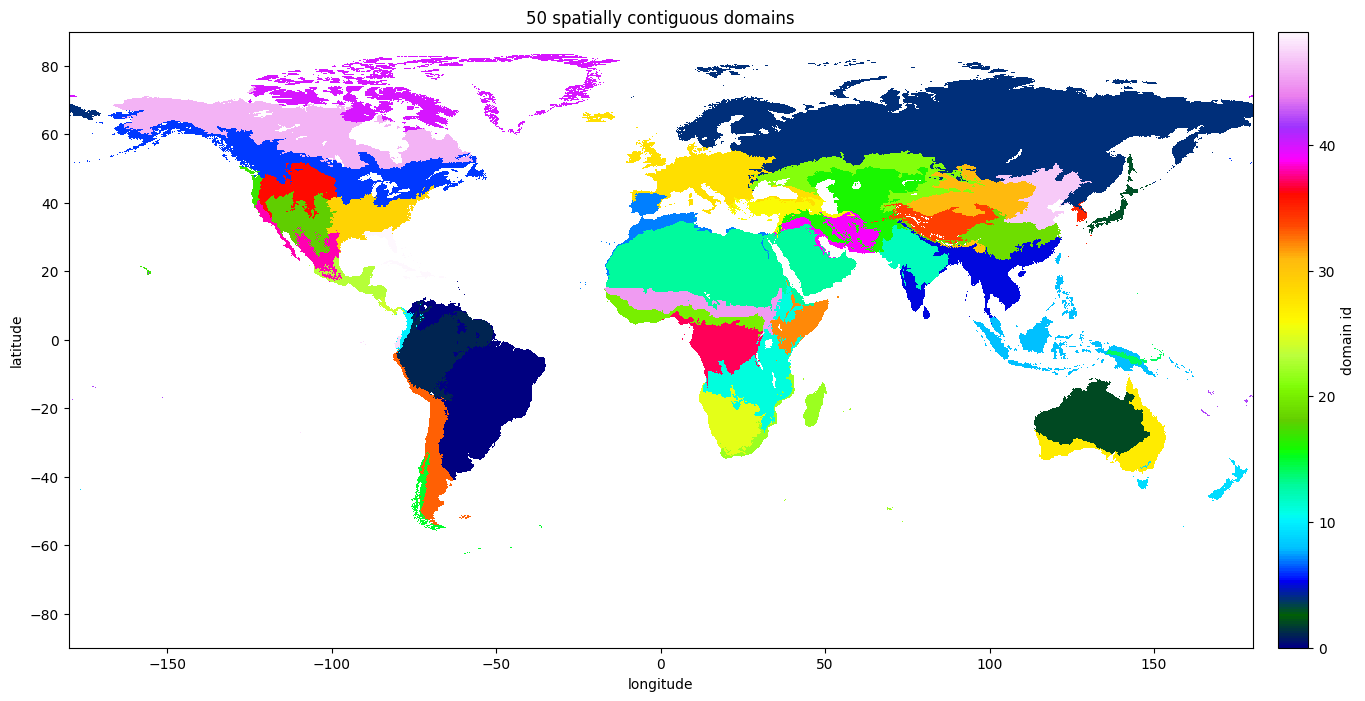

In [45]:
n_domains = len(np.unique(labels))

fig, ax = plt.subplots(figsize=(16, 8))
im = ax.pcolormesh(lon, lat, masked, cmap="gist_ncar", shading="auto")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"{n_domains} spatially contiguous domains")
fig.colorbar(im, ax=ax, label="domain id", fraction=0.025, pad=0.02)
plt.show()

In [46]:
fig.savefig("domains_map.png", dpi=300, bbox_inches="tight")

In [47]:
# attach domain id on the same grid as "ecoregion"
# -1 marks nodata pixels or ecoregions excluded during the alignment fix
domain_da = xr.DataArray(
    domain_grid.astype("int16"),
    dims=ds["ecoregion"].dims,
    coords={dim: ds[dim] for dim in ds["ecoregion"].dims},
    name="domain_id",
    attrs={
        "description": "spatially contiguous climate domain id from agglomerative clustering",
        "nodata_value": -1
    }
)

domain_ds = domain_da.to_dataset()

In [48]:
domain_zarr_path = "ecoregion_domains.zarr"
domain_ds.to_zarr(domain_zarr_path, mode="w", consolidated=True)